         date  down_hole_presure  down_hole_temperature  \
0  13/07/2008            260.867                103.293   
1  14/07/2008            256.248                104.018   
2  15/07/2008            254.983                103.967   
3  16/07/2008            251.476                104.211   
4  17/07/2008            249.346                104.339   

   production_pipe_pressure  choke_size_pct  well_head_presure  \
0                   160.152          21.053            100.715   
1                   156.650          27.223             99.598   
2                   156.333          27.278             98.650   
3                   155.817          30.651             95.659   
4                   155.761          32.563             93.585   

   well_head_temperature  choke_size_pressure      oil  
0                 52.382               69.539  1735.26  
1                 71.115               68.016   592.36  
2                 67.591               66.949  2532.21  
3                 73

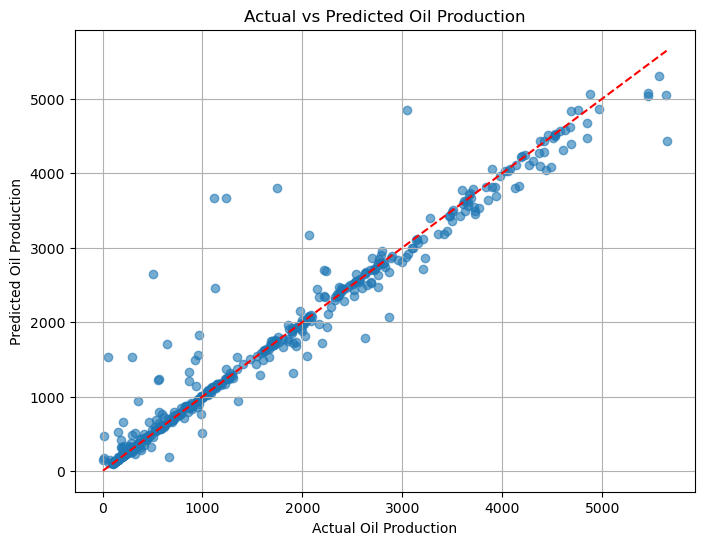

In [17]:
#RANDOM FOREST
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("volve_field_data.csv")

print(df.head())
df.dropna(inplace=True)


df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Extract useful date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

# Remove original date column
df.drop("date", axis=1, inplace=True)

X = df.drop("oil", axis=1)
y = df["oil"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("=" * 40)
print("Model Performance")
print("=" * 40)

print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Oil Production")
plt.ylabel("Predicted Oil Production")
plt.title("Actual vs Predicted Oil Production")
plt.grid(True)
plt.show()



In [15]:
LINEAR REGREESION

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



df = pd.read_csv("volve_field_data.csv")


df.dropna(inplace=True)

# -----------------------------
# Convert Date Column
# -----------------------------
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Extract date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

# Remove original date column
df.drop("date", axis=1, inplace=True)



X = df.drop("oil", axis=1)
y = df["oil"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

# -----------------------------
# Evaluate
# -----------------------------
print("=" * 40)
print("Linear Regression Performance")
print("=" * 40)

print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")

# -----------------------------
# Coefficients
# -----------------------------
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients")
print(coefficients)




Linear Regression Performance
MAE       : 402.1646
MSE       : 378110.1457
RMSE      : 614.9066
R² Score  : 0.7864

Feature Coefficients
                    Feature  Coefficient
0         down_hole_presure    -3.668638
1     down_hole_temperature    10.805380
2  production_pipe_pressure    -0.684619
3            choke_size_pct    -0.298909
4         well_head_presure     3.634349
5     well_head_temperature    14.671034
6       choke_size_pressure     4.230467
7                      year  -412.382476
8                     month   -23.332940
9                       day     1.639575

Model saved as 'linear_regression_oil_model.pkl'


K-Means Evaluation
Number of Clusters      : 3
Inertia                : 16463.505558592326
Silhouette Score       : 0.38223456702180014
Davies-Bouldin Index   : 0.9796728713390296
Calinski-Harabasz Score: 1027.2277102667117


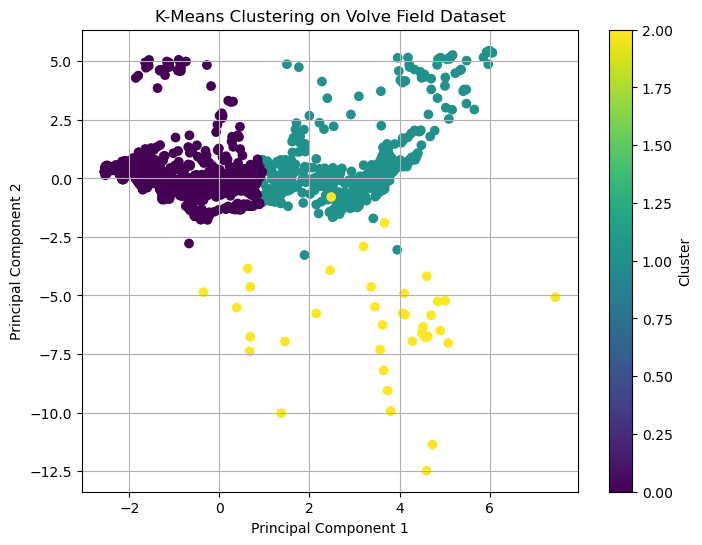

In [6]:
#unsupervised ,k-means clustering

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("volve_field_data.csv")

# Remove missing values
df.dropna(inplace=True)

# -----------------------------
# Convert Date Column
# -----------------------------
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df.drop("date", axis=1, inplace=True)

# -----------------------------
# Features (Exclude Target)
# -----------------------------
X = df.drop("oil", axis=1)

# -----------------------------
# Standardize Features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train K-Means
# -----------------------------
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# -----------------------------
# Evaluation
# -----------------------------
print("=" * 40)
print("K-Means Evaluation")
print("=" * 40)

print("Number of Clusters      :", kmeans.n_clusters)
print("Inertia                :", kmeans.inertia_)
print("Silhouette Score       :", silhouette_score(X_scaled, clusters))
print("Davies-Bouldin Index   :", davies_bouldin_score(X_scaled, clusters))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, clusters))

# -----------------------------
# PCA Visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on Volve Field Dataset")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.show()

Neural Network Evaluation
MAE       : 153.5369
MSE       : 104875.2034
RMSE      : 323.8444
R² Score  : 0.9407


C:\Users\AkashPrasanth\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


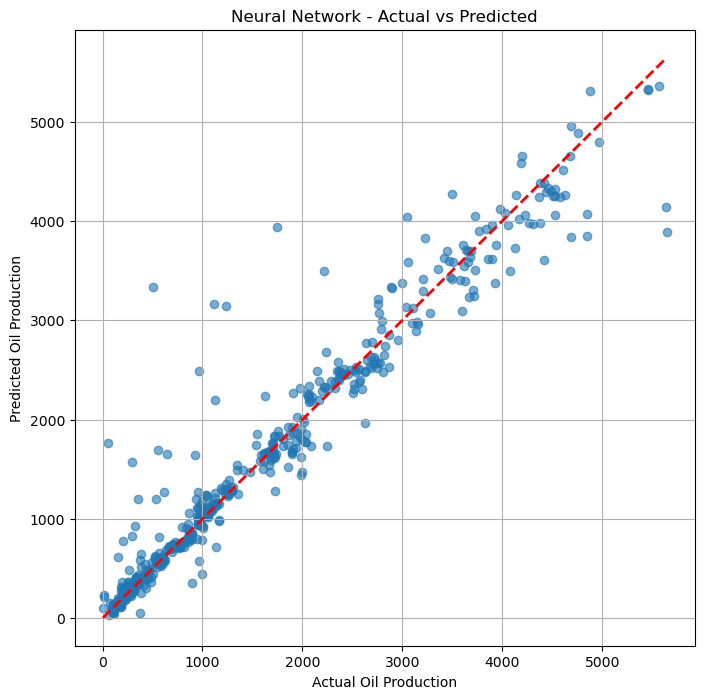

In [7]:
#Neural network
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset

df = pd.read_csv("volve_field_data.csv")

df.dropna(inplace=True)


# Convert Date

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df.drop("date", axis=1, inplace=True)


# Features and Target

X = df.drop("oil", axis=1)
y = df["oil"]


# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Neural Network Model

model = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


# Evaluation

print("=" * 40)
print("Neural Network Evaluation")
print("=" * 40)

print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")


# Actual vs Predicted Plot

plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Oil Production")
plt.ylabel("Predicted Oil Production")
plt.title("Neural Network - Actual vs Predicted")
plt.grid(True)

plt.show()

In [12]:
# ----------------------------
# Reinforcement Learning: Q-Learning
# ----------------------------

import numpy as np
import random

# Environment (5 states)
# 0 -> Start
# 4 -> Goal

n_states = 5
n_actions = 2  # 0 = left, 1 = right

Q = np.zeros((n_states, n_actions))

learning_rate = 0.1
discount = 0.9
epsilon = 0.2

episodes = 1000

def step(state, action):
    if action == 1:  # move right
        next_state = min(state + 1, n_states - 1)
    else:  # move left
        next_state = max(state - 1, 0)

    reward = 1 if next_state == n_states - 1 else 0
    done = next_state == n_states - 1

    return next_state, reward, done

# Training loop
for _ in range(episodes):
    state = 0
    done = False

    while not done:
        # exploration vs exploitation
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, 1)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done = step(state, action)

        # Q-learning update
        Q[state, action] = Q[state, action] + learning_rate * (
            reward + discount * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state

print("Trained Q-table:")
print(Q)

# Test learned policy
state = 0
path = [state]

while state != n_states - 1:
    action = np.argmax(Q[state])
    state, _, _ = step(state, action)
    path.append(state)

print("Learned path:", path)

Trained Q-table:
[[0.65609417 0.729     ]
 [0.65609855 0.81      ]
 [0.72899532 0.9       ]
 [0.80999688 1.        ]
 [0.         0.        ]]
Learned path: [0, 1, 2, 3, 4]


In [3]:
#NLP
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("IMDB Dataset.csv") 




df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['review']
y = df['sentiment']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000))
])


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------------
# 8. Test on custom review
# ------------------------
sample = ["This movie was absolutely amazing and full of emotion"]
print("Prediction:", model.predict(sample))

Accuracy: 0.889

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Prediction: [1]
